In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

Matplotlib is building the font cache; this may take a moment.


In [18]:
fear = pd.read_csv("../data/fear_greed_index.csv")
trade = pd.read_csv("../data/historical_data.csv")

In [20]:
fear.head()



,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [21]:
fear.head()



,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [22]:
trade.head()



,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [23]:
fear.info()



<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [24]:
trade.info()



<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [25]:
fear.describe()



,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [26]:
trade.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [30]:
fear.isnull().sum()



timestamp         0
value             0
classification    0
date              0
dtype: int64

In [29]:
trade.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [31]:
fear = fear.drop_duplicates()

trade = trade.drop_duplicates()

In [32]:
fear["date"] = pd.to_datetime(fear["date"])

In [34]:
trade["Timestamp IST"].head(10)

0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
5    02-12-2024 22:50
6    02-12-2024 22:50
7    02-12-2024 22:50
8    02-12-2024 22:50
9    02-12-2024 22:50
Name: Timestamp IST, dtype: str

In [35]:
trade["Timestamp IST"] = pd.to_datetime(
    trade["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

In [36]:
trade["date"] = trade["Timestamp IST"].dt.date
fear["date"] = fear["date"].dt.date

In [37]:
df = pd.merge(
    trade,
    fear,
    on="date",
    how="left"
)

In [38]:
df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'timestamp', 'value', 'classification'],
      dtype='str')

In [39]:
df["Profit"] = df["Closed PnL"]

In [40]:
df["Win"] = df["Closed PnL"] > 0

In [41]:
df["Trade Value"] = (
    df["Execution Price"] *
    df["Size Tokens"]
)

In [42]:
len(df)

211224

In [43]:
df["Account"].nunique()

32

In [44]:
df["classification"].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

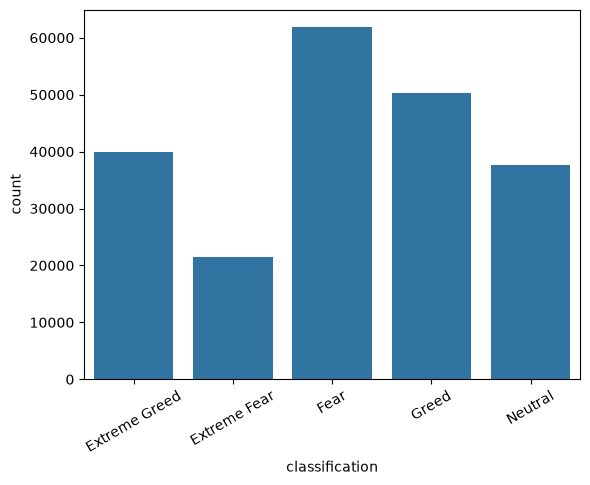

In [45]:
sns.countplot(data=df, x="classification")
plt.xticks(rotation=30)
plt.show()

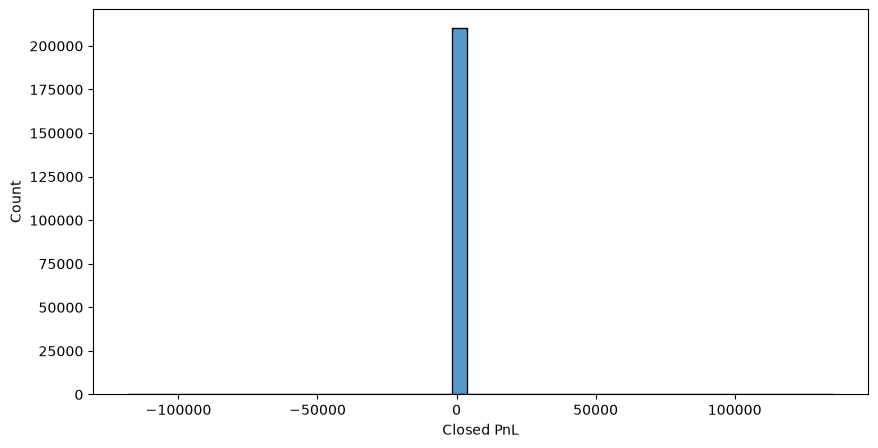

In [46]:
plt.figure(figsize=(10,5))
sns.histplot(df["Closed PnL"], bins=50)
plt.show()

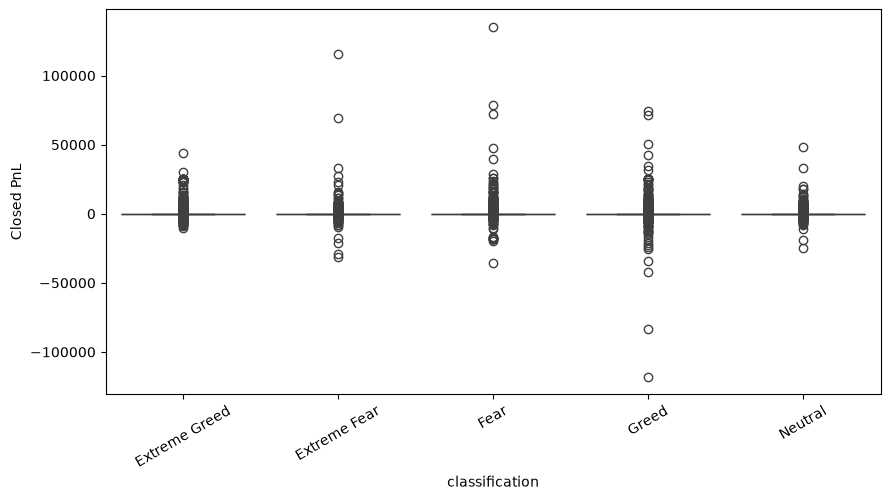

In [47]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="classification",
    y="Closed PnL",
    data=df
)

plt.xticks(rotation=30)
plt.show()

In [48]:
df.groupby("classification")["Closed PnL"].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

<Axes: xlabel='classification'>

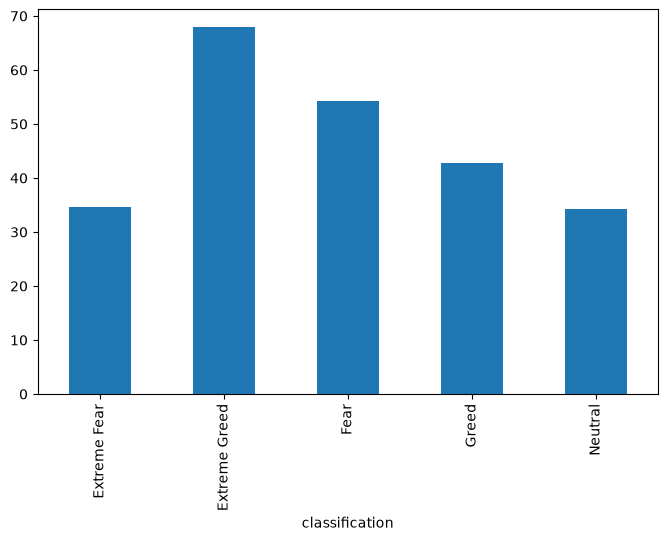

In [49]:
df.groupby("classification")["Closed PnL"].mean().plot(
    kind="bar",
    figsize=(8,5)
)

In [50]:
df.groupby("classification")["Size USD"].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

<Axes: xlabel='classification', ylabel='Size USD'>

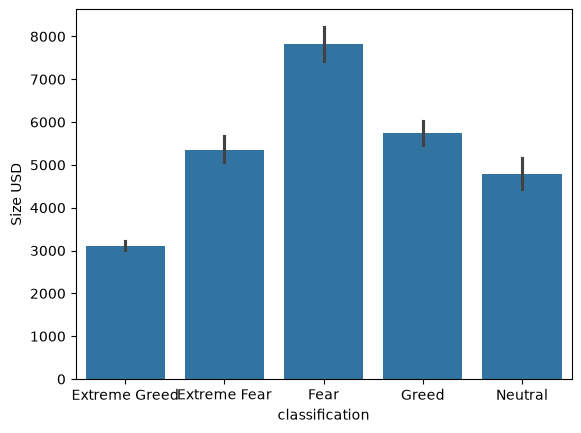

In [51]:
sns.barplot(
    data=df,
    x="classification",
    y="Size USD"
)

In [52]:
df.groupby("classification")["Fee"].mean()

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64

<Axes: xlabel='Side', ylabel='count'>

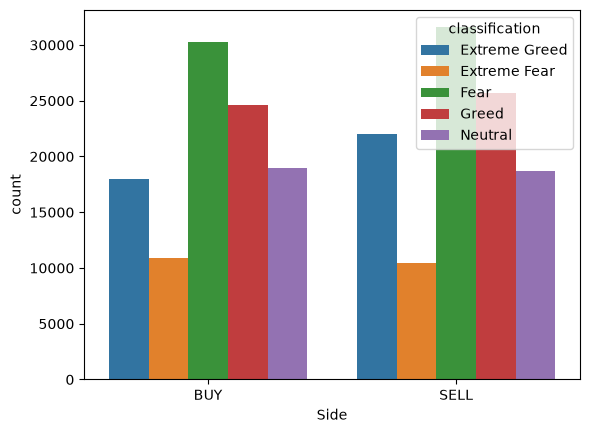

In [54]:
sns.countplot(
    data=df,
    x="Side",
    hue="classification"
)

In [55]:
top = df.groupby("Account")["Closed PnL"].sum()

top.sort_values(ascending=False).head(10)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

<Axes: xlabel='Account'>

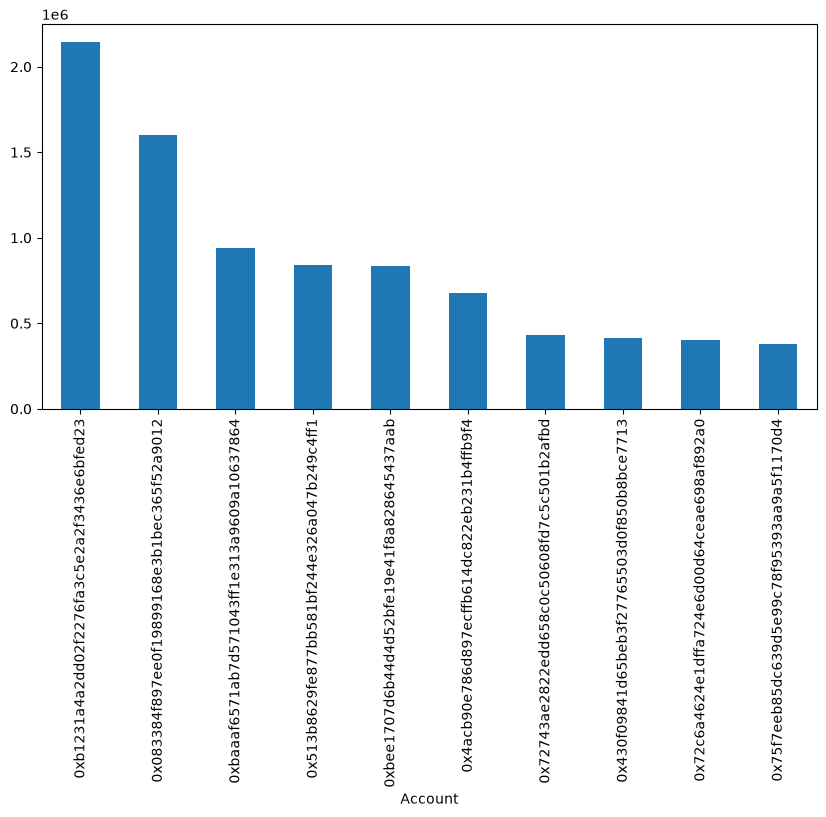

In [56]:
top.sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(10,5)
)

In [57]:
df.groupby("Account")["Win"].mean().sort_values(
    ascending=False
)

Account
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    0.810876
0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0    0.573141
0x2c229d22b100a7beb69122eed721cee9b24011dd    0.519914
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    0.486226
0x430f09841d65beb3f27765503d0f850b8bce7713    0.484236
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    0.475904
0xbaaaf6571ab7d571043ff1e313a9609a10637864    0.467582
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    0.455215
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f    0.452213
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    0.442720
0xb899e522b5715391ae1d4f137653e7906c5e2115    0.438611
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    0.438585
0x6d6a4b953f202f8df5bed40692e7fd865318264a    0.431795
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    0.428230
0xae5eacaf9c6b9111fd53034a602c192a04e082ed    0.408526
0x513b8629fe877bb581bf244e326a047b249c4ff1    0.401193
0x8170715b3b381dffb7062c0298972d4727a0a63b    0.382743
0x4f93fead39b70a1824f981a54d4e55b278e9f760    0.360364
0x

In [58]:
df["Hour"] = pd.to_datetime(
    df["Timestamp IST"]
).dt.hour

<Axes: xlabel='Hour', ylabel='count'>

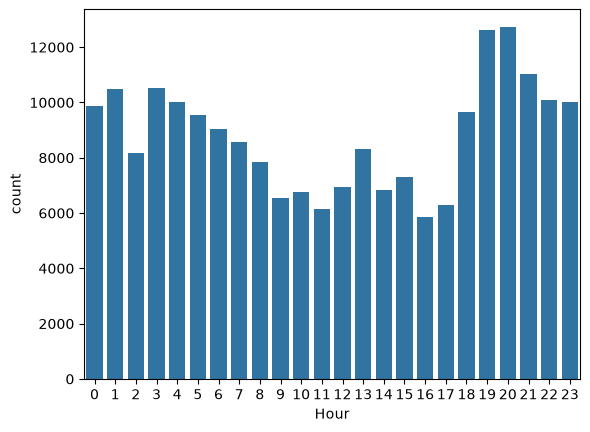

In [59]:
sns.countplot(data=df, x="Hour")

<Axes: >

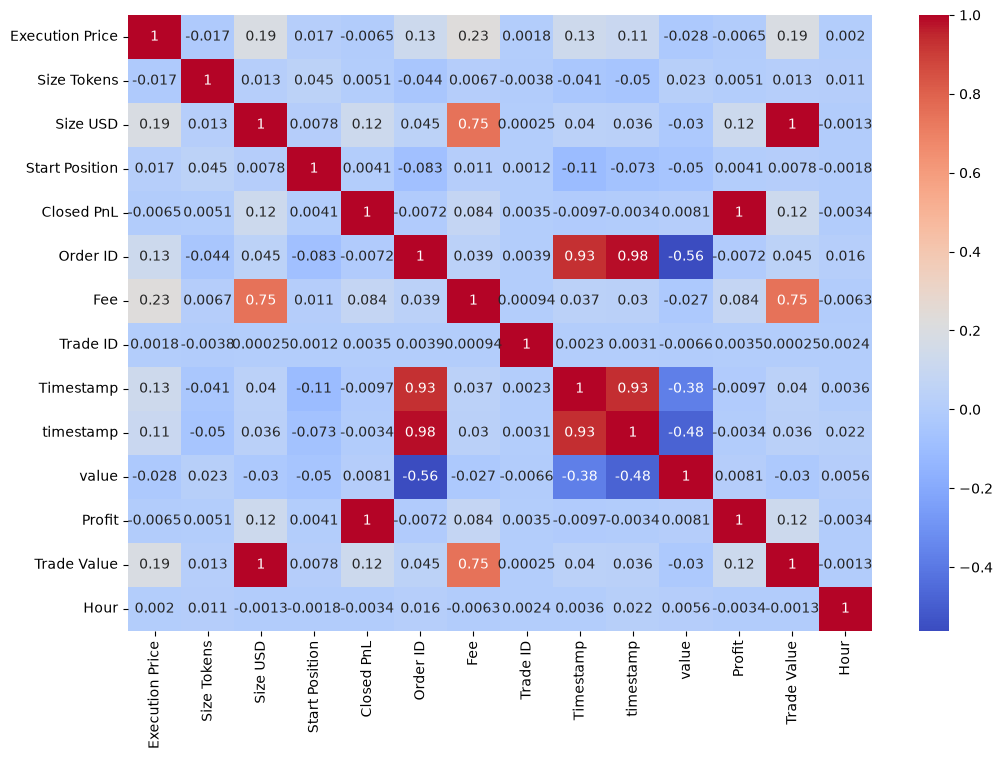

In [60]:
numeric = df.select_dtypes(include="number")

corr = numeric.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

In [61]:
fear_profit = df[
    df["classification"]=="Fear"
]["Closed PnL"]

greed_profit = df[
    df["classification"]=="Greed"
]["Closed PnL"]

t,p = ttest_ind(
    fear_profit,
    greed_profit,
    nan_policy="omit"
)

print(t)
print(p)

1.884727797757762
0.05946918109970857


In [62]:
df.to_csv(
    "merged_cleaned_data.csv",
    index=False
)

After analyzing the data, summarize findings such as:

1.Which sentiment (Fear/Greed) had higher average profit.

2.Whether traders used larger positions during Greed.

3.Whether win rate changed with market sentiment.

4.Which hours showed the most trading activity.

5.Whether higher fees were associated with larger trades.

6.Which traders consistently generated positive PnL.

Only include insights that are actually supported by your analysis.